# Fire and Engineering Annual Risk Analysis

This notebook provides a separate annual analysis of the Fire and Engineering treaty groups. All premium-based calculations use `prm_gross_written`. The analysis covers underwriting years from 2012 onward, consistent with the source notebook.

Claim frequency is policy-based: policies with positive gross incurred claims divided by total policies. This is not a count of individual claim notifications because the source data is policy-level.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

NAVY = '#0B2E5C'
BLUE = '#1F4E96'
GOLD = '#C9A227'
RED = '#B22222'
PALE_BLUE = '#D9E4F5'
GREY = '#6B7A99'
GROUP_COLORS = {'Fire': BLUE, 'Engineering': GOLD}

plt.rcParams.update({
    'font.size': 10,
    'axes.edgecolor': '#CCCCCC',
    'axes.grid': True,
    'grid.color': '#E5E5E5',
    'grid.linewidth': 0.6,
    'axes.axisbelow': True,
})

df = pd.read_excel('data.xlsx', sheet_name='Sheet1')
required = ['pol_no', 'pol_uw_year', 'treaty_group_name', 'prm_gross_written', 'clm_gross_incurred']
missing_required = [column for column in required if column not in df.columns]
if missing_required:
    raise KeyError(f'Missing required columns: {missing_required}')

df = df[df['pol_uw_year'] >= 2012].copy()
df['clm_gross_incurred'] = df['clm_gross_incurred'].fillna(0)
df['prm_gross_written'] = df['prm_gross_written'].fillna(0)
df['claim_policy'] = df['clm_gross_incurred'] > 0
groups = [group for group in ['Fire', 'Engineering'] if group in df['treaty_group_name'].dropna().unique()]
if not groups:
    raise ValueError('Neither Fire nor Engineering was found in treaty_group_name.')

print(f'Rows analysed: {len(df):,}')
print(f'Years: {int(df.pol_uw_year.min())} to {int(df.pol_uw_year.max())}')
print(f'Treaty groups found: {groups}')

c:\Users\matukunda\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Rows analysed: 10,077
Years: 2012 to 2026
Treaty groups found: ['Fire', 'Engineering']


## Data quality focus: client type and construction class

This section focuses on the two classification fields used for segmentation: `clt_type` and `ri_construction_class_name`. It checks completeness, distinct values, and whether missingness is concentrated in Fire, Engineering, or particular underwriting years.


clt_type
Populated: 74.9%   Missing, blank, or undefined: 25.1%
Values:
clt_type
Individual           4432
Corporate            3119
Missing/undefined    2526

ri_construction_class_name
Populated: 58.6%   Missing, blank, or undefined: 41.4%
Values:
ri_construction_class_name
Class A              5889
Missing/undefined    4173
Class B                 8
Class D                 5
Class C                 2

COMPLETENESS BY TREATY GROUP (%)
                   policies  client_type_populated  construction_class_populated
treaty_group_name                                                               
Engineering             923                   83.0                          84.5
Fire                   9154                   74.1                          56.0

MISSINGNESS BY UNDERWRITING YEAR (%)
             policies  client_type_missing  construction_class_missing
pol_uw_year                                                           
2012              606                 93.9            

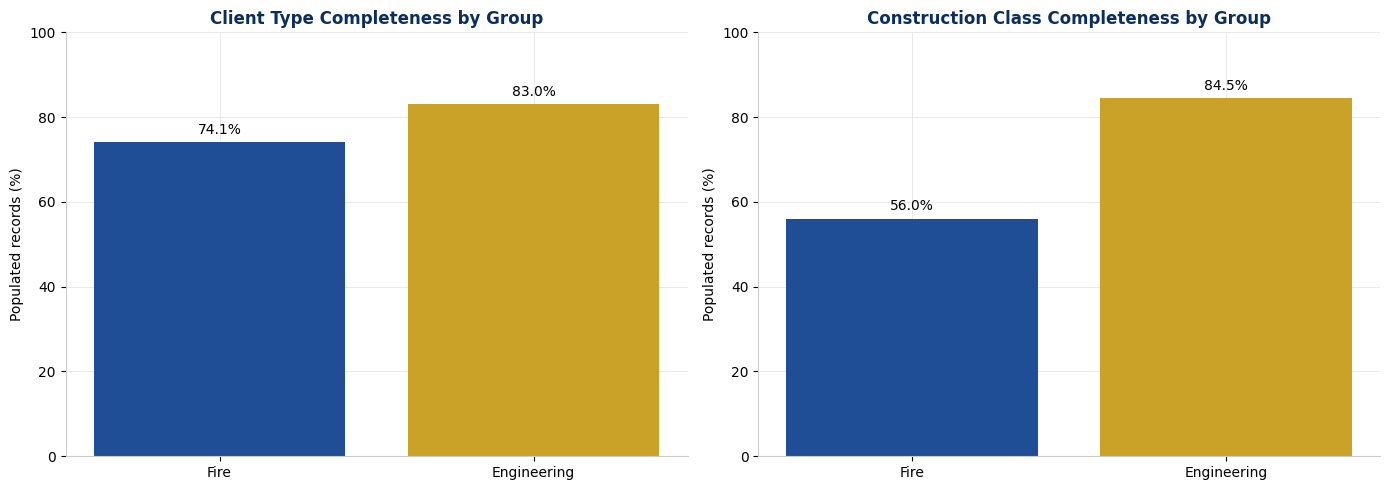

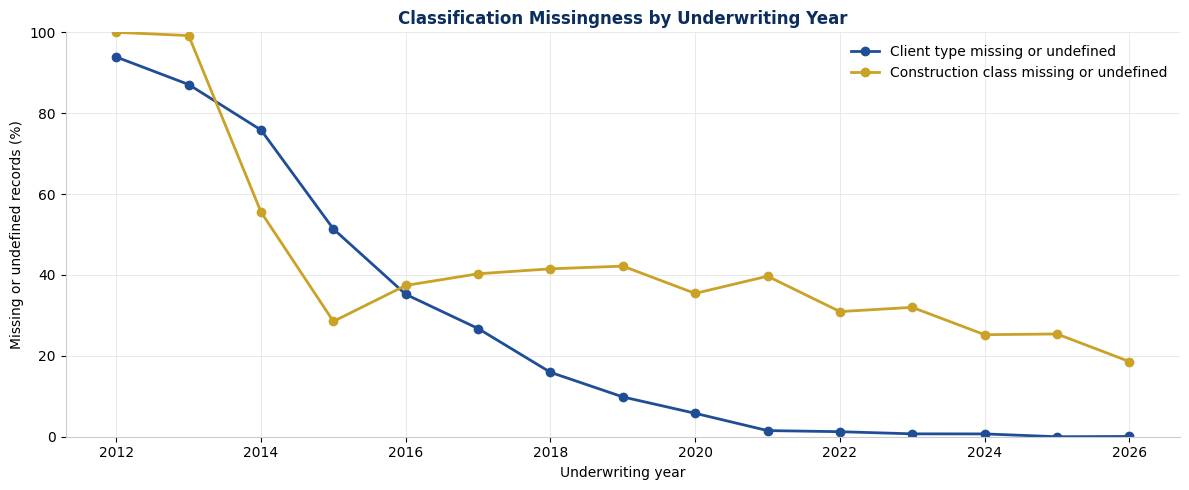

In [10]:
quality_fields = ['clt_type', 'ri_construction_class_name']
missing_markers = {'', 'undefined', 'null', 'none', 'nan'}

def quality_status(series):
    normalized = series.fillna('').astype(str).str.strip().str.lower()
    return normalized.isin(missing_markers)

for field in quality_fields:
    missing = quality_status(df[field])
    values = df[field].fillna('Missing').astype(str).str.strip()
    display_values = values.mask(missing, 'Missing/undefined')
    print(f'\n{field}')
    print(f'Populated: {(~missing).mean():.1%}   Missing, blank, or undefined: {missing.mean():.1%}')
    print('Values:')
    print(display_values.value_counts(dropna=False).head(15).to_string())

quality_by_group = (df.assign(
        clt_type_present=~quality_status(df['clt_type']),
        construction_class_present=~quality_status(df['ri_construction_class_name'])
    )
    .groupby('treaty_group_name')
    .agg(policies=('pol_no', 'count'),
         client_type_populated=('clt_type_present', 'mean'),
         construction_class_populated=('construction_class_present', 'mean')))
print('\nCOMPLETENESS BY TREATY GROUP (%)')
quality_group_display = quality_by_group.copy()
quality_group_display['client_type_populated'] *= 100
quality_group_display['construction_class_populated'] *= 100
print(quality_group_display.round(1).to_string())

quality_by_year = (df.assign(
        client_type_missing=quality_status(df['clt_type']),
        construction_class_missing=quality_status(df['ri_construction_class_name'])
    )
    .groupby('pol_uw_year')
    .agg(policies=('pol_no', 'count'),
         client_type_missing=('client_type_missing', 'mean'),
         construction_class_missing=('construction_class_missing', 'mean')))
print('\nMISSINGNESS BY UNDERWRITING YEAR (%)')
quality_year_display = quality_by_year.copy()
quality_year_display['client_type_missing'] *= 100
quality_year_display['construction_class_missing'] *= 100
print(quality_year_display.round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, field, title in zip(
    axes,
    quality_fields,
    ['Client Type Completeness by Group', 'Construction Class Completeness by Group']
):
    present = ~quality_status(df[field])
    completeness = (df.assign(present=present)
                    .groupby('treaty_group_name')['present'].mean()
                    .reindex(groups))
    ax.bar(completeness.index, completeness * 100,
           color=[GROUP_COLORS[group] for group in completeness.index])
    ax.set_title(title, color=NAVY, fontweight='bold')
    ax.set_ylabel('Populated records (%)')
    ax.set_ylim(0, 100)
    for index, value in enumerate(completeness * 100):
        ax.text(index, value + 2, f'{value:.1f}%', ha='center')
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
for field, label, color in [
    ('client_type_missing', 'Client type missing or undefined', BLUE),
    ('construction_class_missing', 'Construction class missing or undefined', GOLD),
]:
    ax.plot(quality_by_year.index, quality_by_year[field] * 100,
            marker='o', linewidth=2, color=color, label=label)
ax.set_title('Classification Missingness by Underwriting Year', color=NAVY, fontweight='bold')
ax.set_xlabel('Underwriting year')
ax.set_ylabel('Missing or undefined records (%)')
ax.set_ylim(0, 100)
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Annual summary tables

The loss ratio is gross incurred claims divided by `prm_gross_written`. Average claim severity is gross incurred claims divided by claiming policies, so it describes the average incurred amount among policies with positive incurred claims.

In [3]:
annual = (df.groupby(['treaty_group_name', 'pol_uw_year'])
         .agg(policies=('pol_no', 'count'),
              claim_policies=('claim_policy', 'sum'),
              prm_gross_written=('prm_gross_written', 'sum'),
              clm_gross_incurred=('clm_gross_incurred', 'sum'))
         .reset_index())
annual['claim_frequency'] = annual['claim_policies'] / annual['policies']
annual['loss_ratio'] = annual['clm_gross_incurred'] / annual['prm_gross_written'].replace(0, np.nan)
annual['average_claim_severity'] = (annual['clm_gross_incurred'] /
                                     annual['claim_policies'].replace(0, np.nan))

display_columns = ['pol_uw_year', 'policies', 'claim_policies', 'claim_frequency',
                   'prm_gross_written', 'clm_gross_incurred', 'loss_ratio',
                   'average_claim_severity']
for group in groups:
    table = annual[annual['treaty_group_name'] == group][display_columns].set_index('pol_uw_year')
    print(f'\n{group.upper()} - ANNUAL DETAIL')
    print(table.round({'claim_frequency': 4, 'loss_ratio': 4, 'average_claim_severity': 0}).to_string())

print('\nPORTFOLIO TOTALS BY TREATY GROUP')
totals = (df.groupby('treaty_group_name')
          .agg(policies=('pol_no', 'count'), claim_policies=('claim_policy', 'sum'),
               prm_gross_written=('prm_gross_written', 'sum'),
               clm_gross_incurred=('clm_gross_incurred', 'sum'))
          .reindex(groups))
totals['claim_frequency'] = totals['claim_policies'] / totals['policies']
totals['loss_ratio'] = totals['clm_gross_incurred'] / totals['prm_gross_written'].replace(0, np.nan)
totals['average_claim_severity'] = totals['clm_gross_incurred'] / totals['claim_policies'].replace(0, np.nan)
print(totals.round({'claim_frequency': 4, 'loss_ratio': 4, 'average_claim_severity': 0}).to_string())


FIRE - ANNUAL DETAIL
             policies  claim_policies  claim_frequency  prm_gross_written  clm_gross_incurred  loss_ratio  average_claim_severity
pol_uw_year                                                                                                                      
2012              559               5           0.0089       1.181293e+09        7.043793e+07      0.0596              14087586.0
2013              582               7           0.0120       2.479270e+09        7.784798e+08      0.3140             111211400.0
2014              559              11           0.0197       4.050573e+09        1.327834e+09      0.3278             120712217.0
2015              538              13           0.0242       3.513115e+09        5.566548e+08      0.1585              42819601.0
2016              665              15           0.0226       4.894786e+09        4.125621e+08      0.0843              27504143.0
2017              569              22           0.0387       3.38681

## Portfolio composition and annual premium

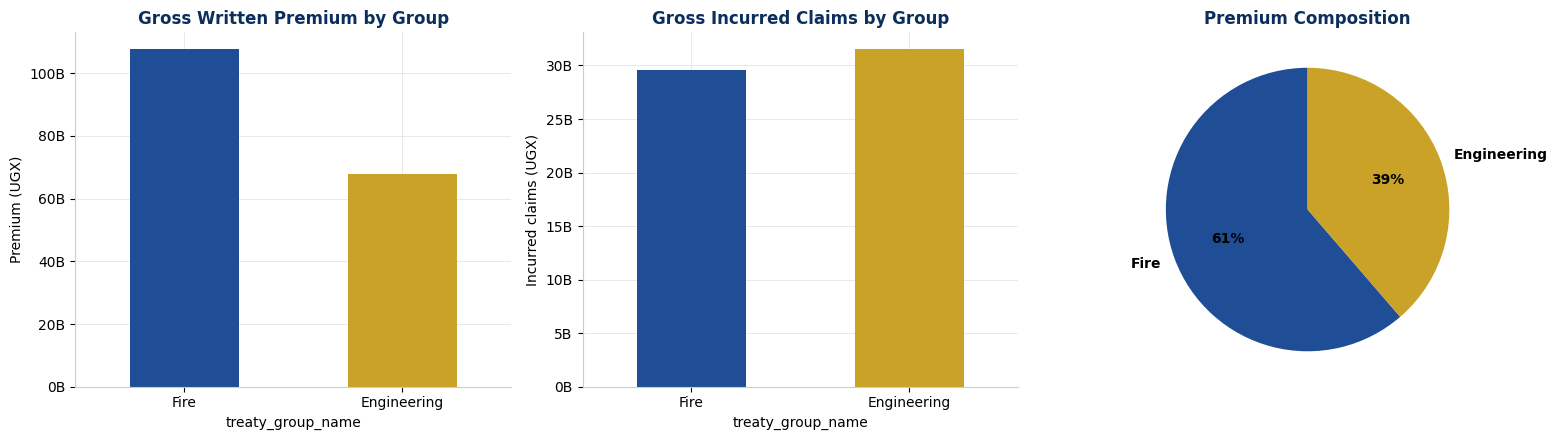

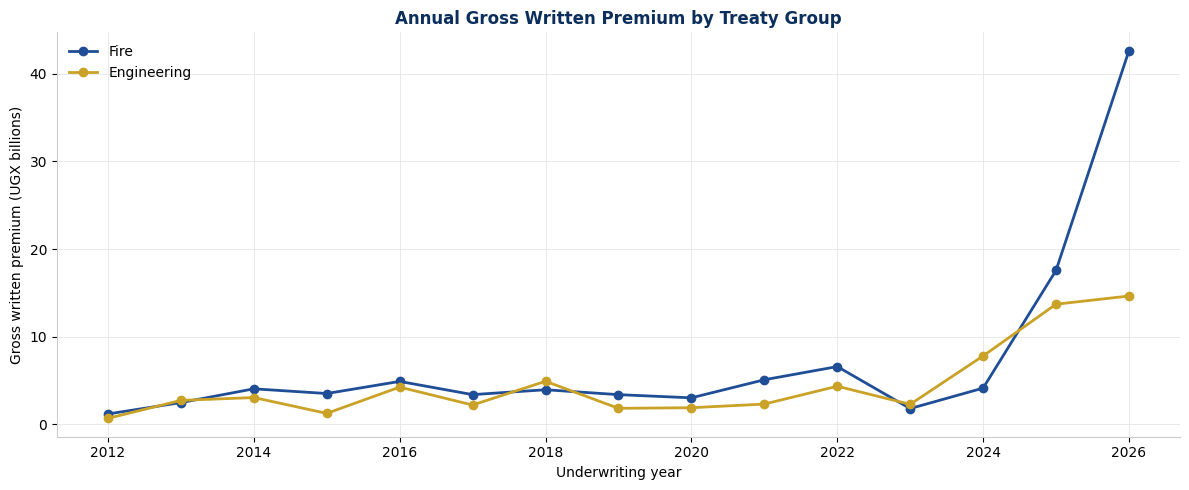

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

totals['prm_gross_written'].plot(kind='bar', ax=axes[0], color=[GROUP_COLORS[g] for g in totals.index])
axes[0].set_title('Gross Written Premium by Group', color=NAVY, fontweight='bold')
axes[0].set_ylabel('Premium (UGX)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: f'{value / 1e9:.0f}B'))
axes[0].tick_params(axis='x', rotation=0)

totals['clm_gross_incurred'].plot(kind='bar', ax=axes[1], color=[GROUP_COLORS[g] for g in totals.index])
axes[1].set_title('Gross Incurred Claims by Group', color=NAVY, fontweight='bold')
axes[1].set_ylabel('Incurred claims (UGX)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: f'{value / 1e9:.0f}B'))
axes[1].tick_params(axis='x', rotation=0)

axes[2].pie(totals['prm_gross_written'], labels=totals.index, colors=[GROUP_COLORS[g] for g in totals.index],
            autopct='%1.0f%%', startangle=90, textprops={'fontweight': 'bold'})
axes[2].set_title('Premium Composition', color=NAVY, fontweight='bold')

for ax in axes[:2]:
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
for group in groups:
    view = annual[annual['treaty_group_name'] == group]
    ax.plot(view['pol_uw_year'], view['prm_gross_written'] / 1e9, marker='o', linewidth=2,
            color=GROUP_COLORS[group], label=group)
ax.set_title('Annual Gross Written Premium by Treaty Group', color=NAVY, fontweight='bold')
ax.set_xlabel('Underwriting year')
ax.set_ylabel('Gross written premium (UGX billions)')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Annual claims, loss ratio, frequency, and severity

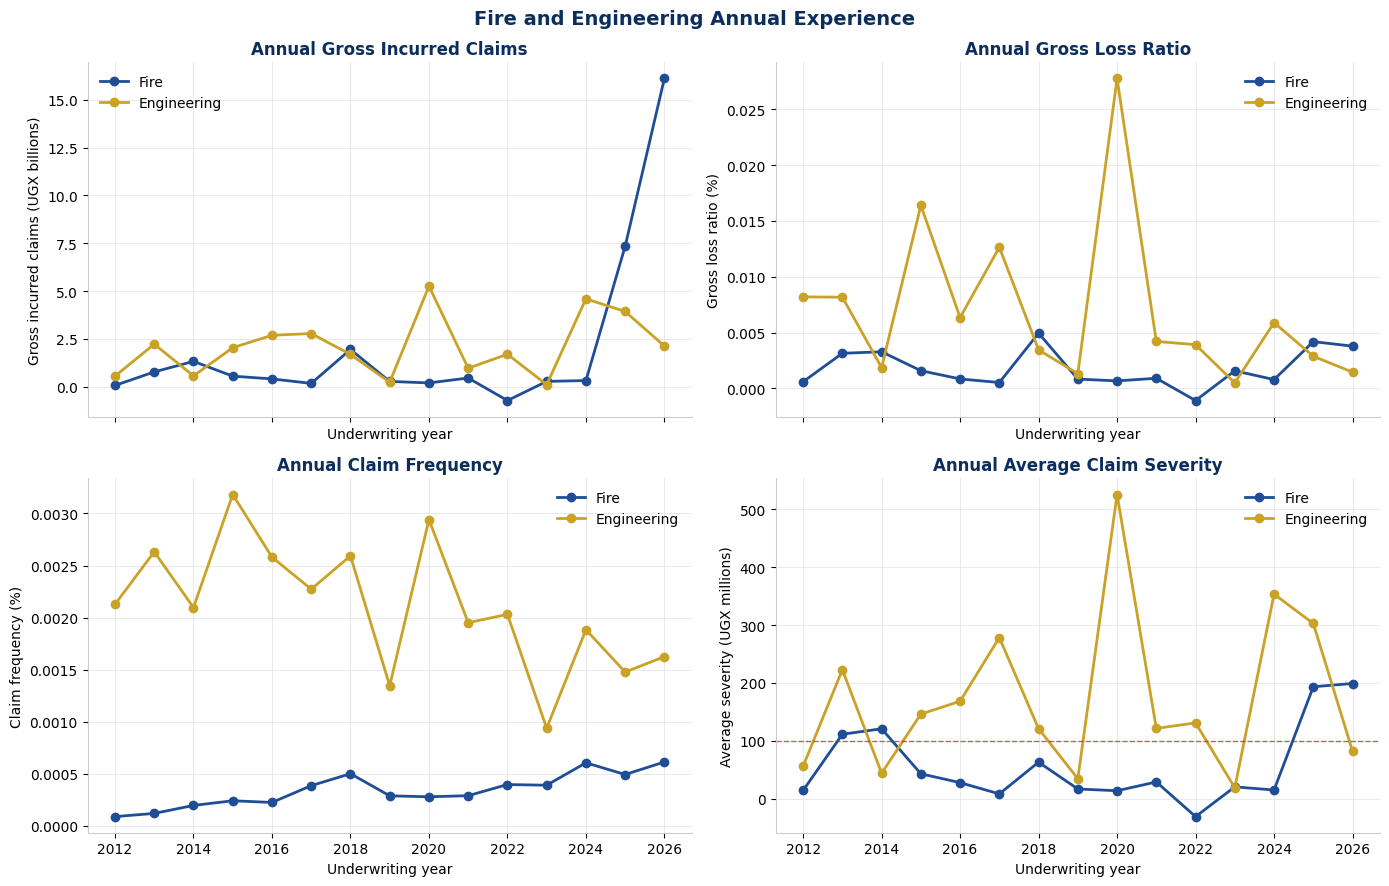

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
metrics = [
    ('clm_gross_incurred', 'Gross incurred claims (UGX billions)', 1e9, 'Annual Gross Incurred Claims'),
    ('loss_ratio', 'Gross loss ratio (%)', 100, 'Annual Gross Loss Ratio'),
    ('claim_frequency', 'Claim frequency (%)', 100, 'Annual Claim Frequency'),
    ('average_claim_severity', 'Average severity (UGX millions)', 1e6, 'Annual Average Claim Severity'),
]
for ax, (column, ylabel, divisor, title) in zip(axes.flat, metrics):
    for group in groups:
        view = annual[annual['treaty_group_name'] == group]
        ax.plot(view['pol_uw_year'], view[column] / divisor, marker='o', linewidth=2,
                color=GROUP_COLORS[group], label=group)
    ax.set_title(title, color=NAVY, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Underwriting year')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False)
axes[1, 1].axhline(100, color=RED, linestyle='--', linewidth=1, alpha=0.7)
plt.suptitle('Fire and Engineering Annual Experience', fontsize=14, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()

## Frequency versus loss ratio: Fire and Engineering separately

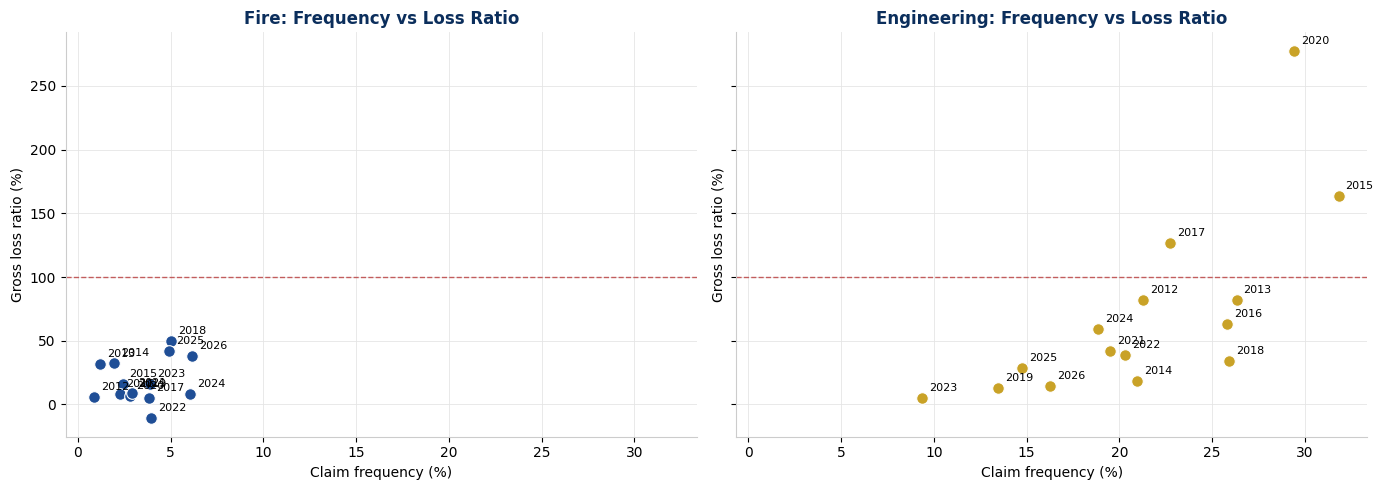

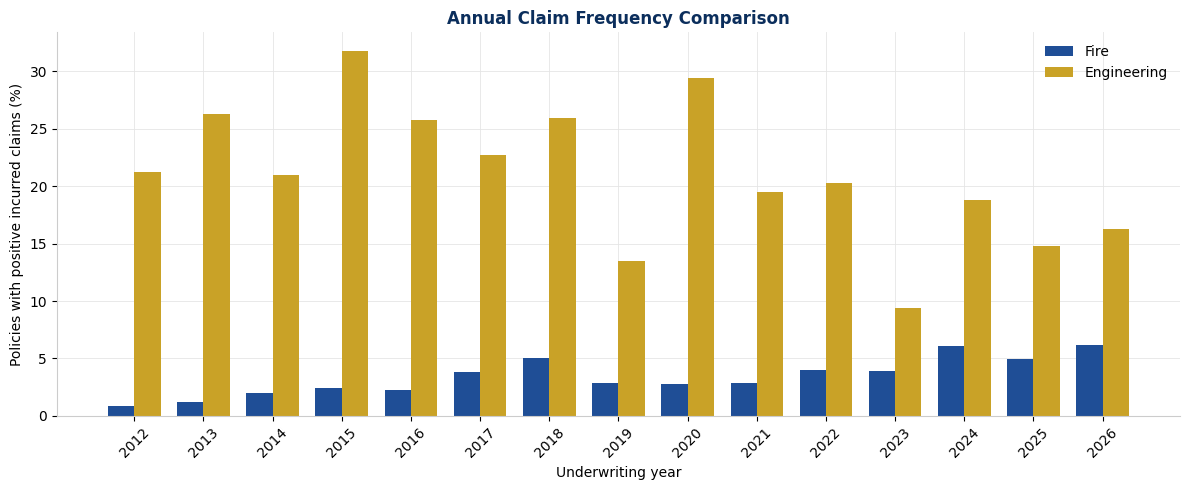

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
for ax, group in zip(axes, groups):
    view = annual[annual['treaty_group_name'] == group].copy()
    ax.scatter(view['claim_frequency'] * 100, view['loss_ratio'] * 100,
               s=70, color=GROUP_COLORS[group], edgecolor='white', linewidth=0.8)
    for _, row in view.iterrows():
        ax.annotate(str(int(row['pol_uw_year'])),
                    (row['claim_frequency'] * 100, row['loss_ratio'] * 100),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    ax.set_title(f'{group}: Frequency vs Loss Ratio', color=NAVY, fontweight='bold')
    ax.set_xlabel('Claim frequency (%)')
    ax.set_ylabel('Gross loss ratio (%)')
    ax.axhline(100, color=RED, linestyle='--', linewidth=1, alpha=0.7)
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
width = 0.38
years = sorted(annual['pol_uw_year'].unique())
x = np.arange(len(years))
for offset, group in zip([-width / 2, width / 2], groups):
    view = annual[annual['treaty_group_name'] == group].set_index('pol_uw_year').reindex(years)
    ax.bar(x + offset, view['claim_frequency'] * 100, width=width,
           color=GROUP_COLORS[group], label=group)
ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45)
ax.set_title('Annual Claim Frequency Comparison', color=NAVY, fontweight='bold')
ax.set_xlabel('Underwriting year')
ax.set_ylabel('Policies with positive incurred claims (%)')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## How to interpret the results

A high claim frequency means a larger share of policies generated positive incurred claims during the underwriting year. A high loss ratio can result from high frequency, high average severity, inadequate premium, or a combination of these.

Compare the frequency and loss-ratio panels together. If frequency rises while average severity is stable, the deterioration is broad-based across more policies. If frequency is stable but loss ratio rises sharply, large claims or premium adequacy are more likely drivers. Engineering should be reviewed separately from Fire because its exposure mix and loss mechanisms differ.

All figures in this notebook are gross of reinsurance and use `prm_gross_written` as the premium denominator. Years with very small policy counts should be treated cautiously, and recent underwriting years may have immature claims development.